In [30]:
# In your new notebook
import pandas as pd
import mplfinance as mpf

# Load the hourly data (use the one from the advanced script)
df = pd.read_parquet('../data/raw/xauusd_h1_2018_present.parquet')
df.set_index('time', inplace=True)
df = df.tz_localize('UTC')

# --- This part is a simplified copy of your feature_engineering_advanced.py ---
# We need to re-calculate the indicators to have them for plotting
import pandas_ta as ta

def calculate_all_indicators(df):
    """Calculates a rich set of technical indicators on the DataFrame."""
    print("Calculating ~20 technical indicators...")
    
    # Use the pandas_ta Strategy builder for efficiency
    # We will list the indicators mentioned in the paper.
    # Note: Some names might be slightly different in pandas_ta.
    # 'kind' is the indicator name, you can find them in the pandas_ta documentation.
    my_study = ta.Study(
        name="RL Paper Indicators",
        description="A collection of ~20 indicators from the RL paper",
        ta=[
            # Momentum Indicators
            {"kind": "rsi"},          # Relative Strength Index
            {"kind": "mom"},          # Momentum
            {"kind": "stoch"},        # Stochastic Oscillator (%K and %D)
            {"kind": "macd"},         # Moving Average Convergence Divergence
            {"kind": "cci"},          # Commodity Channel Index
            {"kind": "roc"},          # Rate of Change
            {"kind": "cmo"},          # Chande Momentum Oscillator
            {"kind": "stochrsi"},     # Stochastic RSI
            {"kind": "willr"},        # Williams %R (similar to Ultimate Oscillator)
            
            # Trend Indicators
            {"kind": "adx"},          # Average Directional Movement Index
            {"kind": "trix"},         # TRIX
            {"kind": "psar"},         # Parabolic SAR
            {"kind": "tema"},         # Triple Exponential Moving Average
            {"kind": "trima"},        # Triangular Moving Average
            {"kind": "wma"},          # Weighted Moving Average
            {"kind": "dema"},         # Double Exponential Moving Average
            
            # Volume and Volatility Indicators
            {"kind": "mfi"},          # Money Flow Index
            {"kind": "bop"},          # Balance of Power
            {"kind": "atr"},          # Average True Range
        ]
    )
    
    # Run the strategy on the DataFrame (this appends all columns)
    df.ta.study(my_study)
    
    return df

df = calculate_all_indicators(df)

# We can't plot data with NaNs, so we'll drop the initial warm-up period
# df.dropna(inplace=True)

print("Data with indicators loaded and cleaned.")
print(df.tail())

Calculating ~20 technical indicators...
Data with indicators loaded and cleaned.
                              open     high      low    close  tick_volume  \
time                                                                         
2025-09-24 04:00:00+00:00  3765.37  3771.85  3755.01  3756.58         4803   
2025-09-24 05:00:00+00:00  3756.49  3759.30  3750.74  3757.09         4149   
2025-09-24 06:00:00+00:00  3757.11  3766.59  3752.37  3765.45         3934   
2025-09-24 07:00:00+00:00  3765.42  3768.30  3763.24  3768.23         3156   
2025-09-24 08:00:00+00:00  3768.17  3776.97  3767.88  3774.93         3901   

                           spread  real_volume     RSI_14  MOM_10  \
time                                                                
2025-09-24 04:00:00+00:00       5            0  47.758268  -17.44   
2025-09-24 05:00:00+00:00      12            0  48.173997  -22.26   
2025-09-24 06:00:00+00:00      14            0  54.557723  -13.71   
2025-09-24 07:00:00+00:00  

In [24]:
df

,open,high,low,close,tick_volume,spread,real_volume,RSI_14,MOM_10,STOCHk_14_3_3,...,PSARl_0.02_0.2,PSARs_0.02_0.2,PSARaf_0.02_0.2,PSARr_0.02_0.2,TEMA_10,TRIMA_10,WMA_10,DEMA_10,BOP,ATRr_14
time,,,,,,,,,,,,,,,,,,,,,
2018-01-02 09:00:00+00:00,1309.81,1310.17,1308.62,1309.28,6186,36,2538457,NaN,NaN,NaN,...,NaN,NaN,0.02,0,NaN,NaN,NaN,NaN,-0.341935,NaN
2018-01-02 10:00:00+00:00,1309.28,1310.73,1308.40,1310.12,7079,36,3035023,100.000000,NaN,NaN,...,NaN,1310.730000,0.02,1,NaN,NaN,NaN,NaN,0.360515,NaN
2018-01-02 11:00:00+00:00,1310.10,1312.21,1309.88,1312.14,6350,36,2737385,100.000000,NaN,NaN,...,1308.400000,NaN,0.02,1,NaN,NaN,NaN,NaN,0.875536,NaN
2018-01-02 12:00:00+00:00,1312.08,1312.74,1310.03,1311.74,7029,36,2963666,96.778276,NaN,NaN,...,1308.476200,NaN,0.04,0,NaN,NaN,NaN,NaN,-0.125461,NaN
2018-01-02 13:00:00+00:00,1311.74,1312.15,1310.04,1310.06,4391,36,1683375,84.469319,NaN,NaN,...,1308.646752,NaN,0.04,0,NaN,NaN,NaN,NaN,-0.796209,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-24 04:00:00+00:00,3765.37,3771.85,3755.01,3756.58,4803,5,0,47.758268,-17.44,26.722400,...,NaN,3783.330852,0.04,0,3758.249749,3766.939167,3764.085273,3762.918832,-0.521971,11.261297
2025-09-24 05:00:00+00:00,3756.49,3759.30,3750.74,3757.09,4149,12,0,48.173997,-22.26,22.005131,...,NaN,3782.067618,0.06,0,3756.162319,3765.311111,3762.245273,3760.625250,0.070093,11.068348
2025-09-24 06:00:00+00:00,3757.11,3766.59,3752.37,3765.45,3934,14,0,54.557723,-13.71,22.759985,...,NaN,3780.187961,0.06,0,3758.760312,3764.000556,3762.330000,3761.736646,0.586498,11.293466


In [26]:
df.columns

Index(['open', 'high', 'low', 'close', 'tick_volume', 'spread', 'real_volume',
       'RSI_14', 'MOM_10', 'STOCHk_14_3_3', 'STOCHd_14_3_3', 'STOCHh_14_3_3',
       'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9', 'CCI_14_0.015',
       'ROC_10', 'CMO_14', 'STOCHRSIk_14_14_3_3', 'STOCHRSId_14_14_3_3',
       'WILLR_14', 'ADX_14', 'ADXR_14_2', 'DMP_14', 'DMN_14', 'TRIX_30_9',
       'TRIXs_30_9', 'PSARl_0.02_0.2', 'PSARs_0.02_0.2', 'PSARaf_0.02_0.2',
       'PSARr_0.02_0.2', 'TEMA_10', 'TRIMA_10', 'WMA_10', 'DEMA_10', 'BOP',
       'ATRr_14'],
      dtype='object')

In [38]:
mpf.make_addplot?

Signature: mpf.make_addplot(data, **kwargs)
Docstring:
Take data (pd.Series, pd.DataFrame, np.ndarray of floats, list of floats), and
kwargs (see valid_addplot_kwargs_table) and construct a correctly structured dict
to be passed into plot() using kwarg `addplot`.  
NOTE WELL: len(data) here must match the len(data) passed into plot()
File:      c:\users\mecha\anaconda3\envs\trade_env\lib\site-packages\mplfinance\plotting.py
Type:      function

c:\Users\mecha\anaconda3\envs\trade_env\Lib\site-packages\mplfinance\plotting.py:707: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  volumeAxes.set_ylim(vymin,vymax)


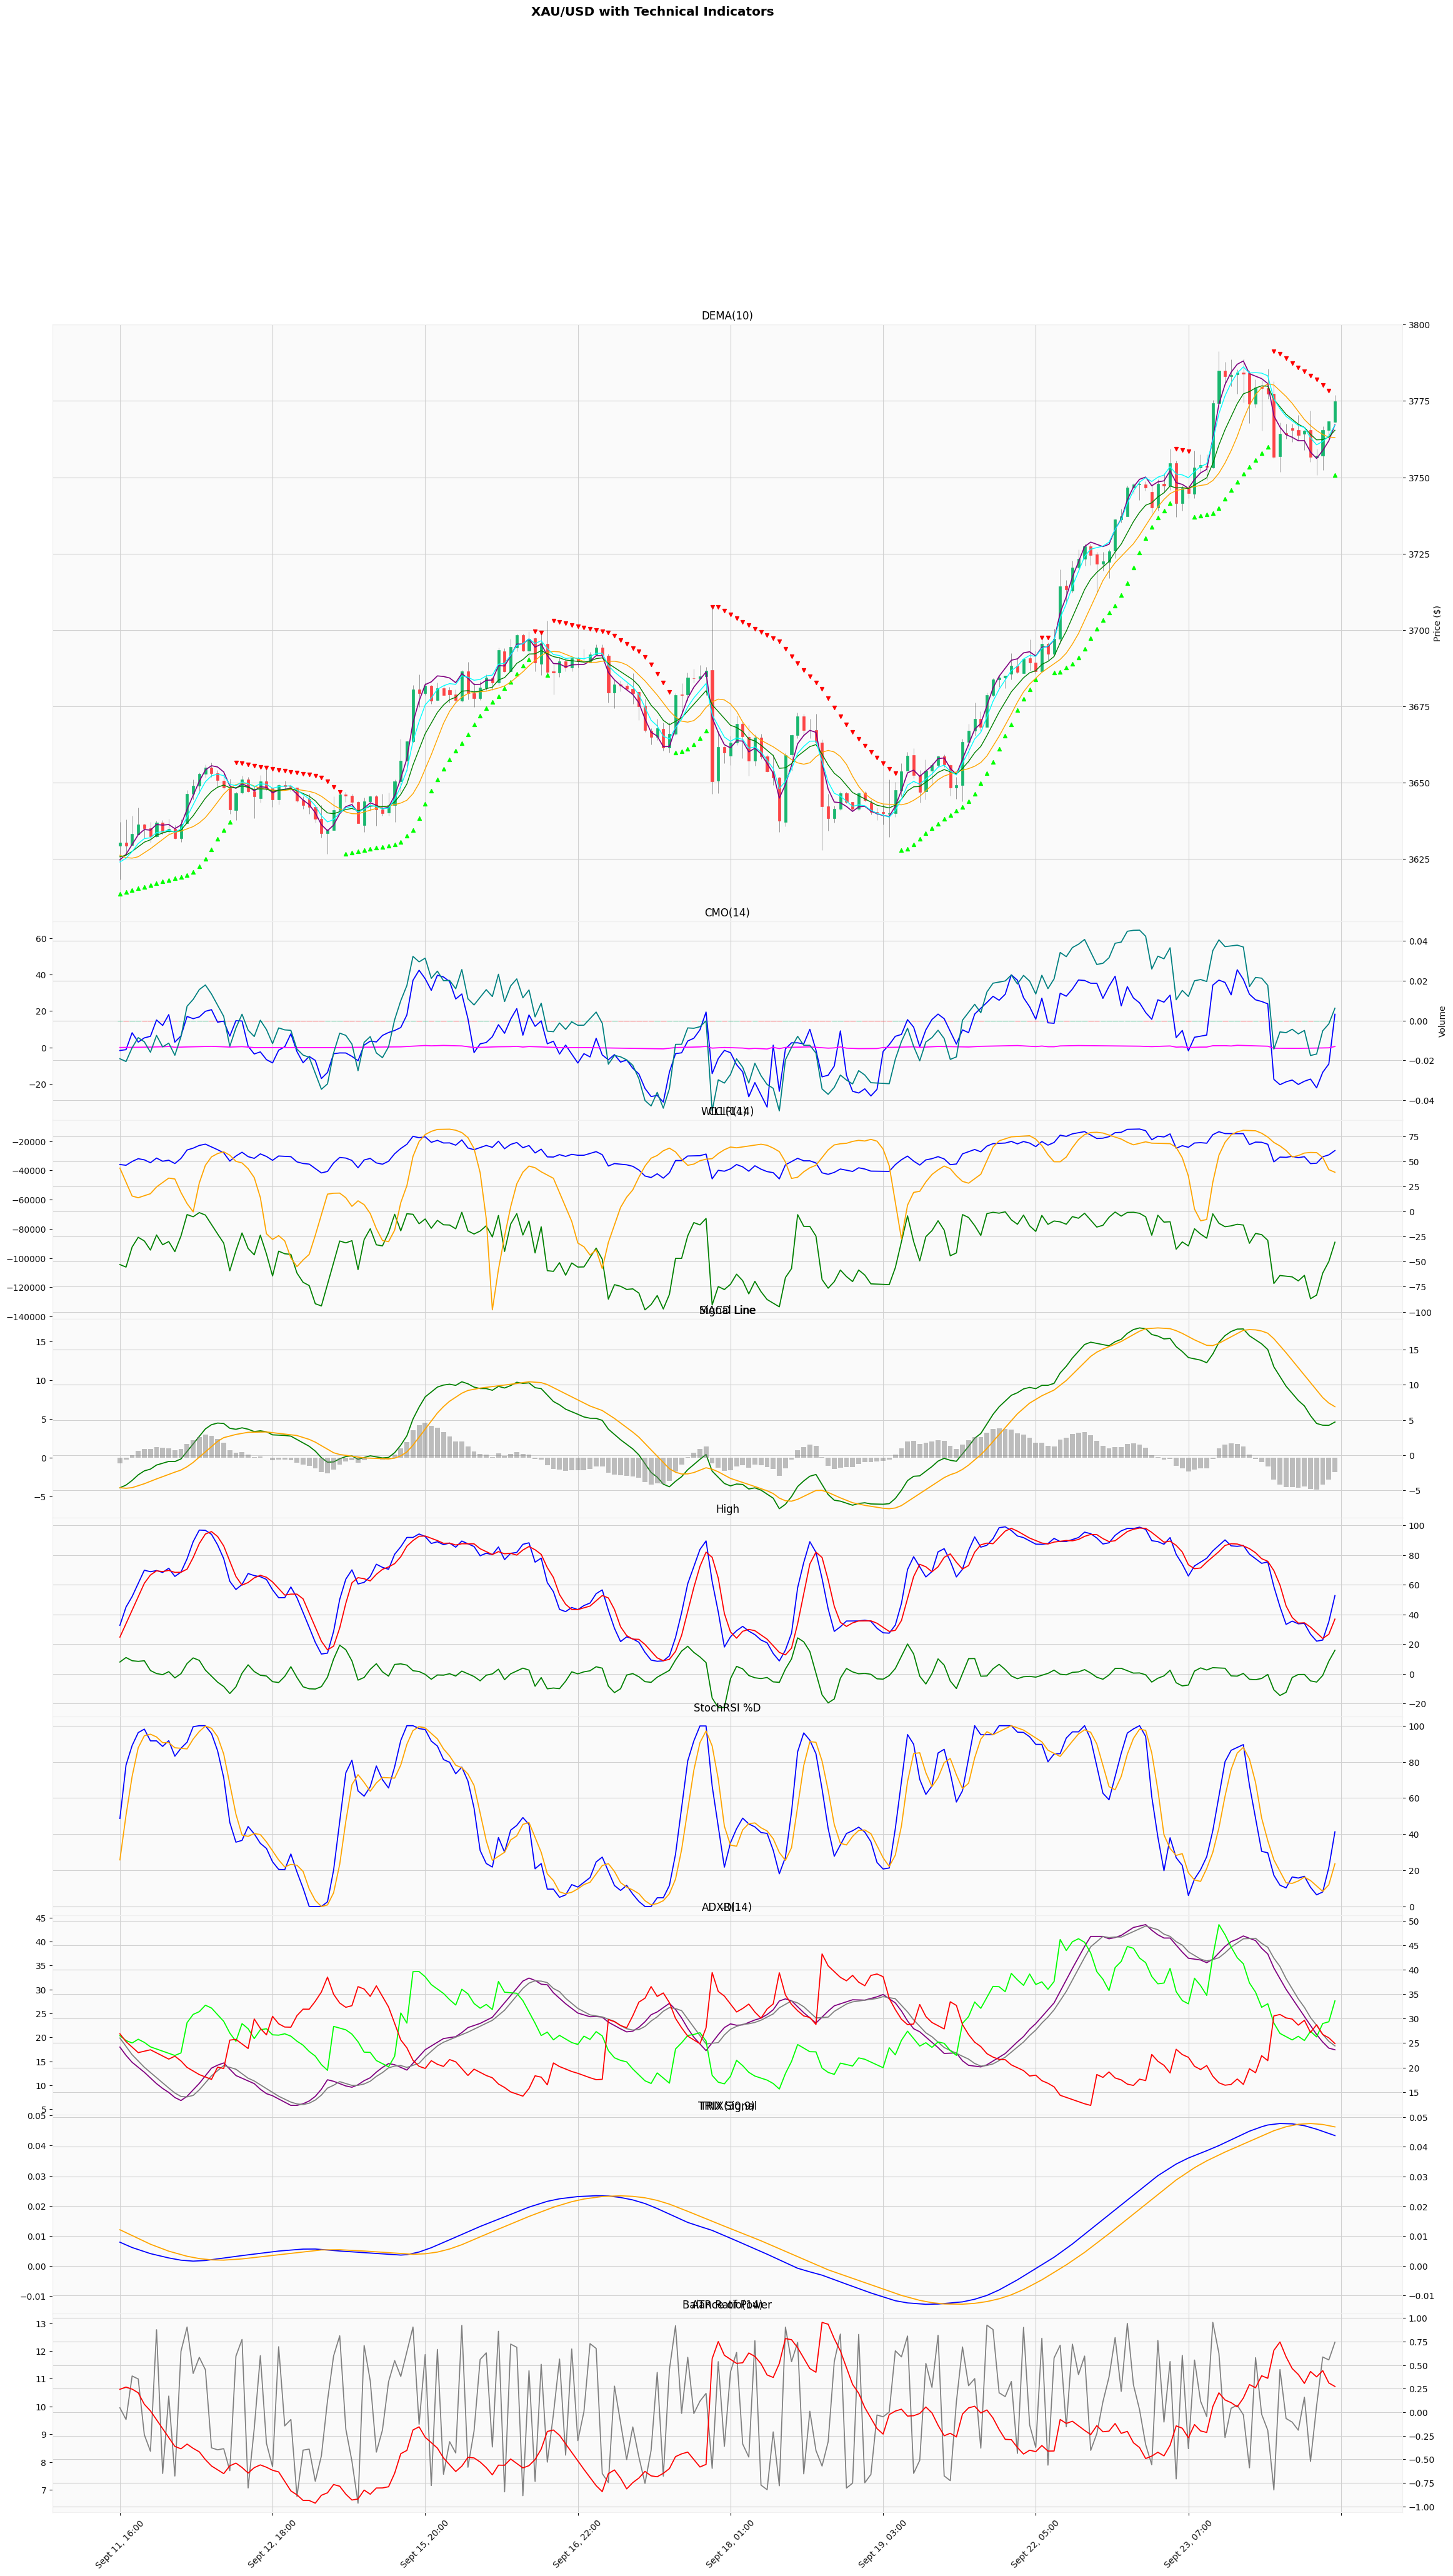

In [42]:

# Select the last 100 hours of data for a clean plot
plot_df = df.tail(200)
plot_df.rename(columns={
    # 'open': 'Open',
    # 'high': 'High',
    # 'low': 'Low',
    # 'close': 'Close',
    'real_volume': 'volume' # We'll rename 'tick_volume' to 'Volume'
}, inplace=True)

# --- Define the Additional Plots (ap) for our indicators ---
# This is a list of dictionaries. Each dictionary defines one panel on the chart.
ap = [
    # === PANEL 0: Main price chart ===
    mpf.make_addplot(plot_df['TEMA_10'], panel=0, color='purple', width=1.2, title='TEMA(10)'),
    mpf.make_addplot(plot_df['TRIMA_10'], panel=0, color='orange', width=1.0, title='TRIMA(10)'),
    mpf.make_addplot(plot_df['WMA_10'], panel=0, color='green', width=1.0, title='WMA(10)'),
    mpf.make_addplot(plot_df['DEMA_10'], panel=0, color='cyan', width=1.0, title='DEMA(10)'),
    # Parabolic SAR (scatter)
    mpf.make_addplot(plot_df['PSARl_0.02_0.2'], type='scatter', marker='^', color='lime', panel=0),
    mpf.make_addplot(plot_df['PSARs_0.02_0.2'], type='scatter', marker='v', color='red', panel=0),

    # === PANEL 1: Momentum Indicators ===
    mpf.make_addplot(plot_df['MOM_10'], panel=1, color='blue', title='Momentum(10)'),
    mpf.make_addplot(plot_df['ROC_10'], panel=1, color='magenta', title='ROC(10)'),
    mpf.make_addplot(plot_df['CMO_14'], panel=1, color='teal', title='CMO(14)'),

    # === PANEL 2: RSI / CCI / WILLR ===
    mpf.make_addplot(plot_df['RSI_14'], panel=2, color='blue', title='RSI(14)'),
    mpf.make_addplot(plot_df['CCI_14_0.015'], panel=2, color='orange', title='CCI(14)'),
    mpf.make_addplot(plot_df['WILLR_14'], panel=2, color='green', title='WILLR(14)'),

    # === PANEL 3: MACD ===
    mpf.make_addplot(plot_df['MACD_12_26_9'], panel=3, color='green', title='MACD Line'),
    mpf.make_addplot(plot_df['MACDh_12_26_9'], type='bar', panel=3, color='gray', alpha=0.5, title='MACD Histogram'),
    mpf.make_addplot(plot_df['MACDs_12_26_9'], panel=3, color='orange', title='Signal Line'),

    # === PANEL 4: Stochastics ===
    mpf.make_addplot(plot_df['STOCHk_14_3_3'], panel=4, color='blue', title='%K'),
    mpf.make_addplot(plot_df['STOCHd_14_3_3'], panel=4, color='red', title='%D'),
    mpf.make_addplot(plot_df['STOCHh_14_3_3'], panel=4, color='green', title='High'),

    # === PANEL 5: StochRSI ===
    mpf.make_addplot(plot_df['STOCHRSIk_14_14_3_3'], panel=5, color='blue', title='StochRSI %K'),
    mpf.make_addplot(plot_df['STOCHRSId_14_14_3_3'], panel=5, color='orange', title='StochRSI %D'),

    # === PANEL 6: ADX and DMI ===
    mpf.make_addplot(plot_df['ADX_14'], panel=6, color='purple', title='ADX(14)'),
    mpf.make_addplot(plot_df['ADXR_14_2'], panel=6, color='gray', title='ADXR(14)'),
    mpf.make_addplot(plot_df['DMP_14'], panel=6, color='lime', title='+DI'),
    mpf.make_addplot(plot_df['DMN_14'], panel=6, color='red', title='-DI'),

    # === PANEL 7: TRIX ===
    mpf.make_addplot(plot_df['TRIX_30_9'], panel=7, color='blue', title='TRIX(30,9)'),
    mpf.make_addplot(plot_df['TRIXs_30_9'], panel=7, color='orange', title='TRIX Signal'),

    # === PANEL 8: BOP and ATR ===
    mpf.make_addplot(plot_df['BOP'], panel=8, color='gray', title='Balance of Power'),
    mpf.make_addplot(plot_df['ATRr_14'], panel=8, color='red', title='ATR Ratio(14)'),
]


# --- Create the Plot ---
# We pass the OHLC data, the volume, and our list of additional plots.
mpf.plot(
    plot_df,
    type='candle',
    style='yahoo',
    title='XAU/USD with Technical Indicators',
    ylabel='Price ($)',
    volume=True,
    panel_ratios=(6, 2, 2, 2, 2, 2, 2, 2, 2),  # one per panel (total 9)
    addplot=ap,
    figsize=(30, 50)
)
